In [7]:
#Paso 1. Cargar los datos y preparar conjuntos
# Importar librerías necesarias
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import pandas as pd

# Cargar el dataset Iris como DataFrame
iris = load_iris(as_frame=True)
df = iris.frame  # Incluye las 4 características + la columna 'target'

# Mostrar las primeras filas del DataFrame
print(df.head())

# Separar las variables predictoras (X) y la variable objetivo (y)
X = df.drop(columns='target')  # Características morfológicas
y = df['target']               # Etiquetas numéricas (0, 1, 2)

# Dividir en conjuntos de entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Conjunto de entrenamiento:", X_train.shape)
print("Conjunto de prueba:", X_test.shape)

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  
Conjunto de entrenamiento: (105, 4)
Conjunto de prueba: (45, 4)


In [8]:
 # Paso 2. Entrenar el modelo con criterio Gini
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Crear el modelo de árbol con el criterio Gini
modelo_iris = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)

# Entrenar el modelo con los datos de entrenamiento
modelo_iris.fit(X_train, y_train)

# Realizar predicciones sobre los datos de prueba
y_pred = modelo_iris.predict(X_test)

# Evaluar el modelo
print("Precisión del modelo:", accuracy_score(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred, target_names=iris.target_names))

Precisión del modelo: 1.0

Reporte de clasificación:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [9]:
 # Paso 2. Entrenar el modelo con criterio Gini con cambio en la profundidad
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Crear el modelo de árbol con el criterio Gini
modelo_iris = DecisionTreeClassifier(criterion='gini', max_depth=1, random_state=0)

# Entrenar el modelo con los datos de entrenamiento
modelo_iris.fit(X_train, y_train)

# Realizar predicciones sobre los datos de prueba
y_pred = modelo_iris.predict(X_test)

# Evaluar el modelo
print("Precisión del modelo:", accuracy_score(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred, target_names=iris.target_names))

Precisión del modelo: 0.7111111111111111

Reporte de clasificación:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       0.50      1.00      0.67        13
   virginica       0.00      0.00      0.00        13

    accuracy                           0.71        45
   macro avg       0.50      0.67      0.56        45
weighted avg       0.57      0.71      0.61        45



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


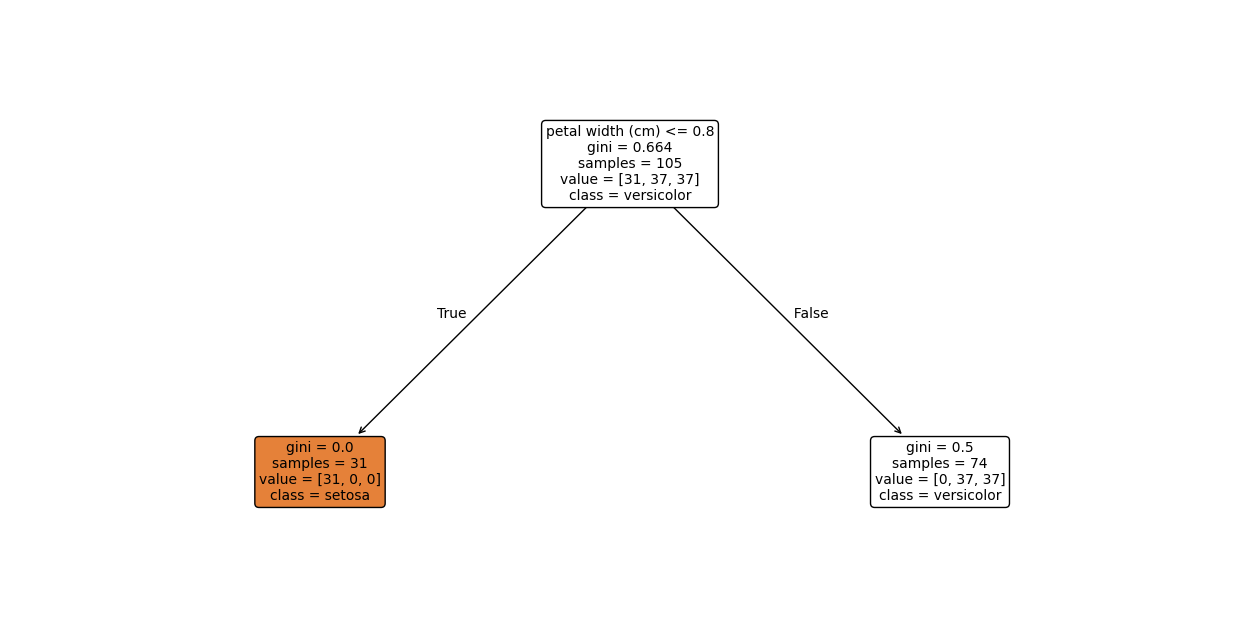

In [10]:
# Paso 3. Visualización del árbol y análisis de impureza
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(16,8))
tree.plot_tree(
    modelo_iris,
    filled=True,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    rounded=True,
    fontsize=10
)
plt.show()